# cloudposterior: Minnesota Radon

Run PyMC MCMC sampling on cloud VMs with one line of code. This notebook demonstrates cloud execution, caching, persistent containers, and cleanup using the classic Radon dataset from Gelman & Hill (2006).

Radon is a radioactive gas that enters homes through the ground. This hierarchical model estimates radon levels across Minnesota counties, with partial pooling to share information between counties with few measurements.

> Run this notebook locally to see the interactive progress display. Some outputs (progress widgets, plots) don't render in GitHub's notebook viewer.

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

import cloudposterior as cp

## Data

919 household radon measurements across 85 Minnesota counties (Gelman & Hill, 2006).

In [2]:
df = pd.read_csv(pm.get_data("radon.csv"))

county_names = df.county.unique()
county_idx = df.county_code.values
log_radon = df.log_radon.values
floor = df.floor.values

print(f"{len(df)} observations, {len(county_names)} counties")

919 observations, 85 counties


## Model

Hierarchical varying-intercepts model with non-centered parameterization. Each county gets its own intercept (partial pooling), and floor level (basement vs first floor) is a fixed effect.

In [3]:
county_names = df.county.unique()
county_idx = df.county_code.values
log_radon = df.log_radon.values
floor = df.floor.values

with pm.Model(name="radon_intercepts", coords={"county": county_names}) as radon:
    # Hyperpriors
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", sigma=2)

    # Non-centered county intercepts
    a_raw = pm.Normal("a_raw", mu=0, sigma=1, dims="county")
    a = pm.Deterministic("a", mu_a + sigma_a * a_raw, dims="county")

    # Fixed effect: floor level
    b_floor = pm.Normal("b_floor", mu=0, sigma=5)

    # Expected value
    mu = a[county_idx] + b_floor * floor

    # Likelihood
    sigma_y = pm.HalfNormal("sigma_y", sigma=2)
    pm.Normal("obs", mu=mu, sigma=sigma_y, observed=log_radon)

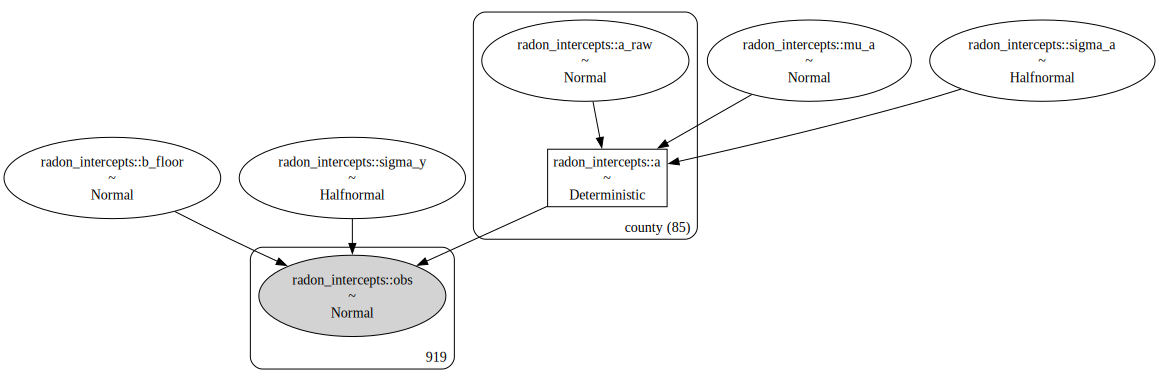

In [4]:
pm.model_to_graphviz(radon)

## Remote execution

`cp.cloud()` intercepts `pm.sample()` and runs it on a cloud VM. The model is uploaded to a volume on first run. Disk caching means re-running this cell returns the cached result instantly.

In [5]:
with cp.cloud(radon, remote=True, cache="disk"):
    idata = pm.sample(draws=2000, tune=1000, chains=4)

## Diagnostics

In [6]:
az.summary(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
radon_intercepts::mu_a,1.493,0.050,1.398,1.587,0.001,0.001,4402.0,5250.0,1.0
radon_intercepts::b_floor,-0.662,0.069,-0.784,-0.528,0.001,0.001,10142.0,5759.0,1.0
radon_intercepts::sigma_a,0.319,0.045,0.239,0.406,0.001,0.001,2601.0,4335.0,1.0
radon_intercepts::sigma_y,0.727,0.018,0.695,0.760,0.000,0.000,9475.0,5089.0,1.0


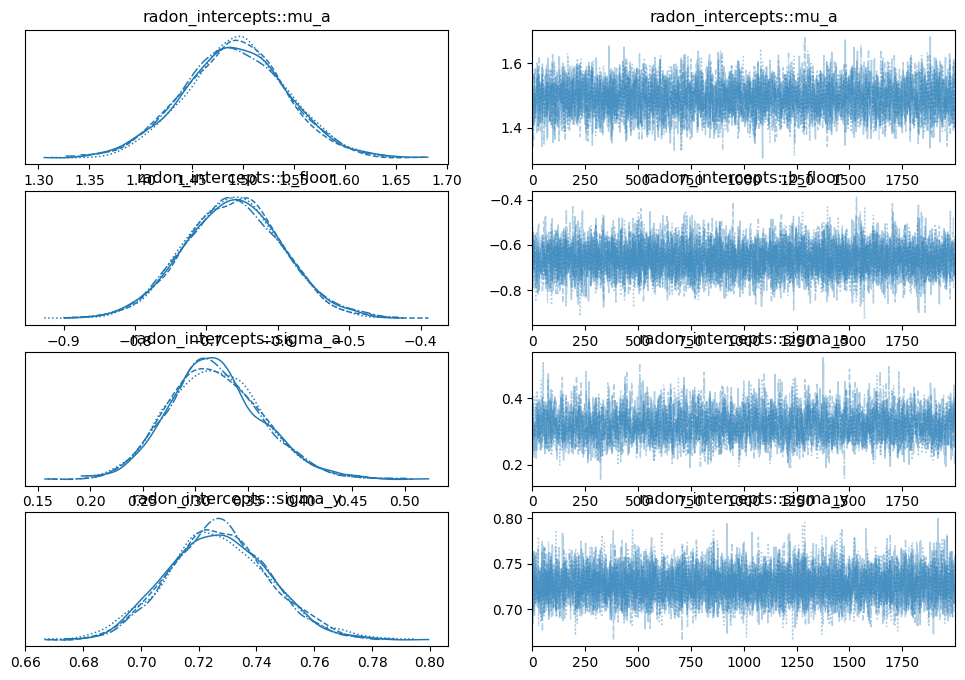

In [7]:
az.plot_trace(idata, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"]);

## Cached result

Re-running the same model with the same settings returns the cached result quickly -- no remote execution, no display. With `cache="disk"`, results persist across kernel restarts. With `cache=True` (the default), results are cached in memory for the session only.

The disk cache is laid out using the model name, sampling parameters, and a hash suffix for uniqueness:

```
.cloudposterior/
├── radon_intercepts/
│   └── draws2000_tune1000_chains4-a3f7b2c9.nc
└── radon_slopes/
    └── draws2000_tune1000_chains4-7c2e5fa8.nc
```

In [8]:
with cp.cloud(radon, remote=True, cache="disk"):
    idata_cached = pm.sample(draws=2000, tune=1000, chains=4)  # instant

## Different model

Adding varying slopes for the floor effect changes the model, so a new payload is uploaded to the volume. If this runs within 20 minutes of the previous execution, the container is still warm and doesn't need to cold-start.

In [9]:
with pm.Model(name="radon_slopes", coords={"county": county_names}) as radon_slopes:
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", sigma=2)
    a_raw = pm.Normal("a_raw", mu=0, sigma=1, dims="county")
    a = pm.Deterministic("a", mu_a + sigma_a * a_raw, dims="county")

    # Varying slopes: floor effect differs by county
    mu_b = pm.Normal("mu_b", mu=0, sigma=5)
    sigma_b = pm.HalfNormal("sigma_b", sigma=2)
    b_raw = pm.Normal("b_raw", mu=0, sigma=1, dims="county")
    b = pm.Deterministic("b", mu_b + sigma_b * b_raw, dims="county")

    mu = a[county_idx] + b[county_idx] * floor

    sigma_y = pm.HalfNormal("sigma_y", sigma=2)
    pm.Normal("obs", mu=mu, sigma=sigma_y, observed=log_radon)

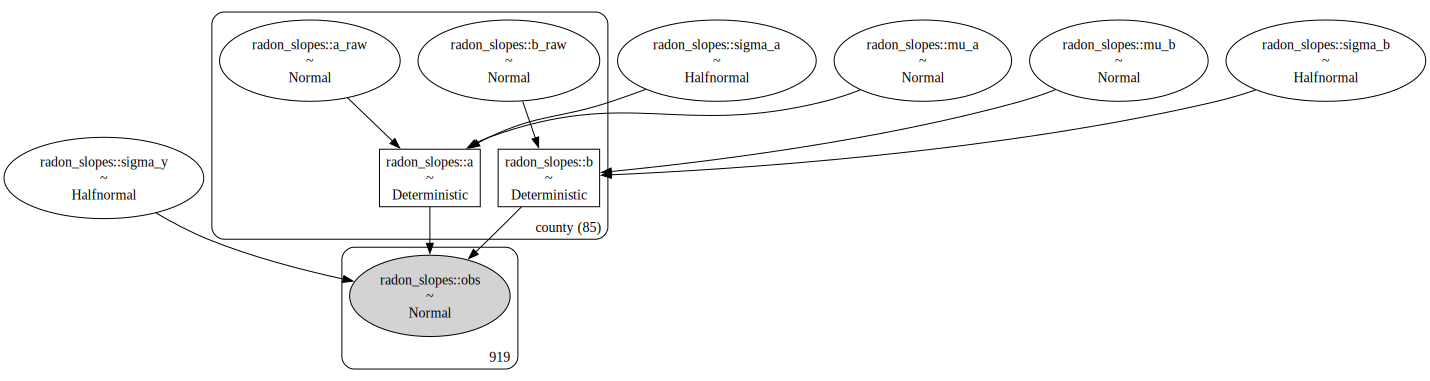

In [10]:
pm.model_to_graphviz(radon_slopes)

In [11]:
with cp.cloud(radon_slopes, remote=True, cache="disk"):
    idata_slopes = pm.sample(draws=2000, tune=1000, chains=4)

In [12]:
az.summary(idata_slopes, filter_vars="like", var_names=["mu_a", "sigma_a", "mu_b", "sigma_b", "sigma_y"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
radon_slopes::mu_a,1.492,0.052,1.396,1.591,0.001,0.001,3065.0,4131.0,1.0
radon_slopes::mu_b,-0.648,0.081,-0.799,-0.496,0.001,0.001,6918.0,5907.0,1.0
radon_slopes::sigma_a,0.326,0.046,0.245,0.415,0.001,0.000,2757.0,4711.0,1.0
radon_slopes::sigma_b,0.262,0.127,0.008,0.465,0.003,0.002,1379.0,2055.0,1.0
radon_slopes::sigma_y,0.720,0.018,0.687,0.756,0.000,0.000,6896.0,5307.0,1.0


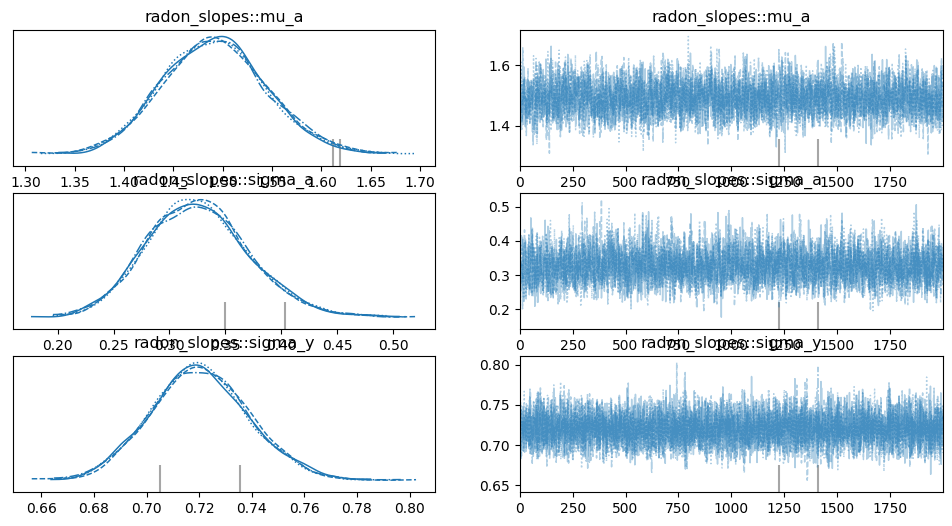

In [13]:
az.plot_trace(idata_slopes, filter_vars="like", var_names=["mu_a", "sigma_a", "b_floor", "sigma_y"]);

## Cleanup

All payloads are stored in a project-scoped volume. Delete it when you're done.

In [14]:
cp.cleanup_volumes()